# 인플레이션 Joy Plot

- **데이터 출처**: 한국은행 ECOS API (품목별 소비자물가지수)
- **참고 교재**: 금융경제학 (박기영 저, 시그마프레스)
- **GitHub**: https://github.com/FinancialEconomicsPython
- **데이터 파일 위치**: https://drive.google.com/drive/folders/1sArqUZKnxWtkNtHe31iD1w-2xCVEhTj0?usp=share_link
- updated: 2026/2/24

---

### 필요 파일 (path_data 폴더에 저장)
- `CPI_items_weights2020.xlsx` : 물가 통계 항목, 가중치, 분류(근원 등) — 분류 변경 시에만 업데이트
- 소비자물가 계산시 포함되는 상품에 대한 가중치를 담을 파일이며 2020년 기준으로 되어 있음.
- 현재 2022년 기준으로 사용 중이므로 추후 수정할 예정임 (https://mods.go.kr/menu.es?mid=b70101040000)

### 주요 DataFrame
- `raw_CPI` : 품목별 물가지수 (수준)
- `raw_core` : 근원물가 품목만 추출한 물가지수
- `raw_growth_yoy` : 전년동월비 증가율
- `raw_growth` : 전월대비 증가율
- `df_trimmed` : 트리밍 후 inflation 분포 데이터

---
## ⚙️ 분석 옵션 설정
> **매번 실행 전 이 셀만 수정하세요.**

In [ ]:
# ============================================================
#  ⚙️  분석 옵션 — 이 셀의 아래 부분에서 필요한 부분만 수정하면 됩니다
# ============================================================

# ── 경로 설정 ────────────────────────────────────────────────
path_figure = "/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/figures/"
path_data   = "/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/data/"

# ── ECOS API 키 ──────────────────────────────────────────────
key_api = 'YOUR_API_KEY_HERE'   # ECOS API 키를 입력하세요

# ── 표본 기간 ─────────────────────────────────────────────────
date_start = '2020-01'          # 시작 연월 (YYYY-MM)
date_end   = '2025-12'          # 종료 연월 (YYYY-MM)

# ── Joy Plot 옵션 ─────────────────────────────────────────────
type_inflation = 'CPI'          # 'CPI' 또는 '근원'
lags           = 12             # 연율화 기준 월수 (예: 1, 3, 6, 12)
qrange         = [0.05, 0.95]   # 트리밍 범위 [하한 분위수, 상한 분위수]

# ── 기타 분석 옵션 ────────────────────────────────────────────
quarterly_only   = True         # Joy Plot에서 분기 데이터만 표시할지 여부
target_inflation = 2.0          # 인플레이션 목표 (%)

# ── 파생 변수 (수정 불필요) ───────────────────────────────────
import pandas as pd
dates_list = pd.date_range(date_start, date_end, freq='MS').strftime('%Y-%m').tolist()

print(f'표본기간: {date_start} ~ {date_end}  ({len(dates_list)}개월)')
print(f'Joy Plot 옵션 — 지표: {type_inflation}, lags: {lags}, qrange: {qrange}')

표본기간: 2020-01 ~ 2025-12  (72개월)
Joy Plot 옵션 — 지표: CPI, lags: 12, qrange: [0.05, 0.95]


In [ ]:
import matplotlib.font_manager as fm
fm.fontManager.__init__()

---
## 1. 환경 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 필요 패키지 설치 (Colab 최초 실행 시)
!pip -q install koreanize-matplotlib joypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.5 MB/s eta 0:00:00


In [ ]:
import os
import json
import platform
import requests
from datetime import date
from urllib.request import urlopen

import numpy as np
import pandas as pd
from pandas import json_normalize
from scipy import stats
from scipy.stats import gaussian_kde

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
import joypy
import koreanize_matplotlib

# ── 디스플레이 설정 ───────────────────────────────────────────
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = '{:,.3f}'.format
pd.options.display.max_rows     = 100
pd.options.display.max_columns  = 10

mpl.rc('axes',  labelsize=14)
mpl.rc('xtick', labelsize=10)
mpl.rc('ytick', labelsize=12)
plt.rcParams['axes.unicode_minus'] = False
sns.set(rc={'figure.figsize': (9, 5)})
sns.set(style='darkgrid')

In [ ]:
def save_fig(fig_id, tight_layout=True, dpi=600):
    """지정된 경로에 PNG로 그림을 저장합니다."""
    path = os.path.join(path_figure, fig_id + '.png')
    print(f'Saving figure → {path}')
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')

---
## 2. 품목 매핑 파일 불러오기
- `CPI_items_weights2020.xlsx` 로드
- 품목명, 가중치, 근원 여부, 관리물가 여부 등 정리

In [ ]:
df = pd.read_excel(path_data + 'CPI_items_weights2020.xlsx', header=0)

# 컬럼명 정리
df.rename(columns={'품목명 (458개)': '품목명', '식료품/에너지': '근원'}, inplace=True)

# 값 정리
df.replace({'근원': True,   '비근원': False,
             '① ':  '신선어개', '②':  '신선채소', ' ③': '신선과실',
             '○':   True,
             'ⓣ':   '주거비',   'ⓤ': '주거비제외서비스', 'ⓥ': '에너지',
             '관리':  True,     '관리제외': False}, inplace=True)
df.fillna(False, inplace=True)
df.set_index('품목명', inplace=True)

# 각 컬럼 값 분포 확인
for col in df.columns[2:]:
    print(f'항목명: {col}')
    print(df[col].value_counts())
    print()

df.head(3)

항목명: 근원
근원
True     309
False    149
Name: count, dtype: int64

항목명: 신선식품
신선식품
False    403
신선채소      26
신선과실      18
신선어개      11
Name: count, dtype: int64

항목명: 생활물가
생활물가
False    314
True     144
Name: count, dtype: int64

항목명: 농산물및석유류제외지수
농산물및석유류제외지수
True     401
False     57
Name: count, dtype: int64

항목명: 식료품및에너지제외지수
식료품및에너지제외지수
True     309
False    149
Name: count, dtype: int64

항목명: 기타특수분류
기타특수분류
False       300
주거비제외서비스    142
에너지           9
주거비           7
Name: count, dtype: int64

항목명: 관리물가
관리물가
False    418
True      40
Name: count, dtype: int64



/tmp/ipykernel_2673/2171936090.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'근원': True,   '비근원': False,
/tmp/ipykernel_2673/2171936090.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


,품목성질별,가중치,근원,신선식품,생활물가,농산물및석유류제외지수,식료품및에너지제외지수,기타특수분류,관리물가
품목명,,,,,,,,,
쌀,농축수산물,5.500,False,False,True,True,False,False,False
현미,농축수산물,0.500,False,False,False,True,False,False,False
찹쌀,농축수산물,0.700,False,False,False,True,False,False,False


In [ ]:
# 품목 분류별 리스트 생성
list_all            = df.index.tolist()
list_manage         = df[df['관리물가'] == True].index.tolist()
list_nomanage       = df[df['관리물가'] == False].index.tolist()
list_core           = df[df['근원'] == True].index.tolist()
list_noncore        = df[df['근원'] == False].index.tolist()
list_core_nomanage  = df[(df['근원'] == True) & (df['관리물가'] == False)].index.tolist()
list_living         = df[df['생활물가'] == True].index.tolist()
list_core_alter     = df[df['농산물및석유류제외지수'] == True].index.tolist()

print(f'소비자물가 항목수          : {len(list_all)}')
print(f'관리물가 항목수            : {len(list_manage)}')
print(f'관리물가 제외              : {len(list_nomanage)}')
print(f'근원품목                   : {len(list_core)}')
print(f'비근원품목                 : {len(list_noncore)}')
print(f'관리물가 제외 근원품목     : {len(list_core_nomanage)}')
print(f'생활물가                   : {len(list_living)}')
print(f'농산물 및 석유류 제외      : {len(list_core_alter)}')

소비자물가 항목수          : 458
관리물가 항목수            : 40
관리물가 제외              : 418
근원품목                   : 309
비근원품목                 : 149
관리물가 제외 근원품목     : 272
생활물가                   : 144
농산물 및 석유류 제외      : 401


---
## 3. ECOS API로 물가 원자료 불러오기

In [ ]:
# ECOS API 품목 코드 목록
CPI_ITEM_CODES = [
    'A01101','A01102','A01103','A01104','A01105','A01106','A01107','A01108','A01109','A01110',
    'A01111','A01112','A01113','A01114','A01115','A01116','A01117','A01118','A01201','A01202',
    'A01203','A01204','A01205','A01206','A01207','A01301','A01302','A01303','A01304','A01305',
    'A01306','A01307','A01308','A01309','A01310','A01311','A01312','A01313','A01314','A01315',
    'A01316','A01317','A01318','A01319','A01401','A01402','A01403','A01404','A01405','A01501',
    'A01502','A01601','A01602','A01603','A01604','A01605','A01606','A01607','A01608','A01609',
    'A01610','A01611','A01612','A01613','A01614','A01615','A01616','A01617','A01618','A01619',
    'A01620','A01701','A01702','A01703','A01704','A01705','A01706','A01707','A01708','A01709',
    'A01710','A01711','A01712','A01713','A01714','A01715','A01716','A01717','A01718','A01719',
    'A01720','A01721','A01722','A01723','A01724','A01725','A01726','A01727','A01728','A01729',
    'A01730','A01801','A01802','A01803','A01804','A01805','A01806','A01807','A01808','A01809',
    'A01810','A01811','A01901','A01902','A01903','A01904','A01905','A01906','A01907','A01908',
    'A01909','A01910','A01911','A01912','A01913','A01914','A01915','A01916','A01917','A01918',
    'A01919','A01920','A02101','A02102','A02201','A02202','A02203','A02204','A02205','A02206',
    'B01101','B01102','B01103','B01104','B01105','B01106','B02101',
    'C01101','C01102','C01103','C01104','C01201','C01202','C01203','C01204','C01205',
    'C01301','C01302','C01303','C01304','C01305','C01306','C01401','C01501','C01502','C01503',
    'C01601','C01602','C02101','C02102','C02103','C02104',
    'D01101','D01102','D03101','D03102','D04101','D04102','D04201','D04202','D04203',
    'D05101','D05201','D05202','D05301','D05302','D05303',
    'E01101','E01102','E01103','E01104','E01105','E01106','E01107','E01108',
    'E02101','E02102','E03101','E03102','E03103','E03104','E03105','E03106','E03107',
    'E03108','E03109','E03110','E03111','E03112','E03113','E03114','E03115','E03201','E03202',
    'E04101','E04102','E04103','E04104','E04105','E04106','E04107','E04108',
    'E05101','E05102','E05103','E06101','E06102','E06103','E06104','E06105','E06106',
    'E06107','E06108','E06109','E06110','E06201','E06202',
    'F01101','F01102','F01103','F01104','F01105','F01106','F01107','F01108','F01109',
    'F01110','F01111','F01112','F01113','F01114','F01115','F01116','F01201','F01202',
    'F01203','F01204','F01205','F01206','F01207','F01208','F01209','F01210',
    'F02101','F02102','F02103','F02104','F02201','F02202','F03101','F03102',
    'G01101','G01102','G01103','G01104','G01105','G01106','G01107','G01108',
    'G02101','G02102','G02103','G02201','G02202','G02203','G02204','G02205','G02206',
    'G02301','G02302','G02303','G02304','G02305','G02306',
    'G03101','G03102','G03201','G03202','G03203','G03301','G03302','G03303','G03401','G03402',
    'H01101','H02101','H03101','H03102','H03103','H03104',
    'I01101','I01102','I01201','I01202','I01203','I01204','I01205',
    'I02101','I02102','I03101','I03102','I03103','I03104','I03105','I03106','I03107',
    'I04101','I04102','I04103','I04104','I04105','I04106','I04107','I04108','I04109','I04110',
    'I04201','I04202','I04203','I04204','I04205','I04206','I04207','I04208',
    'I05101','I05102','I05103','I05104','I05105','I05106','I05201',
    'I05301','I05302','I05303','I05304','I06101','I06102',
    'J01101','J03101','J03102','J03103','J03104','J03105',
    'J04101','J04102','J04103','J04104','J04105','J04106','J04107','J04108','J04109','J04110','J04111',
    'J04201','J04202','J04203',
    'K01101','K01102','K01103','K01104','K01105','K01106','K01107','K01108','K01109','K01110',
    'K01111','K01112','K01113','K01114','K01115','K01116','K01117','K01118','K01119','K01120',
    'K01121','K01122','K01123','K01124','K01125','K01126','K01127','K01128','K01129','K01130',
    'K01131','K01132','K01133','K01134','K01135','K01136','K01137','K01138','K01139',
    'K02101','K02102','K02103','K02104','K02105',
    'L01101','L01102','L01103','L01104','L01105','L01201','L01202','L01203','L01204','L01205',
    'L01206','L01207','L01208','L01209','L01210','L01211','L01212','L01213',
    'L02101','L02102','L02103','L02104','L02105','L02106','L02107','L02108',
    'L03101','L03102','L03103','L03104','L03105','L03106','L03107','L03108','L03109','L03110','L03111'
]
CPI_ITEM_CODES_SET = set(CPI_ITEM_CODES)


def import_cpi(datestart, key_api=key_api):
    """
    ECOS에서 특정 월(datestart, 형식: 'YYYYMM')의
    품목별 소비자물가지수를 불러옵니다.

    Parameters
    ----------
    datestart : str
        조회 연월 (예: '202001')
    key_api : str
        ECOS API 키

    Returns
    -------
    pd.DataFrame
        index=품목명, column=해당 연월, 값=물가지수
    """
    url = (f'http://ecos.bok.or.kr/api/StatisticSearch/{key_api}'
           f'/json/kr/1/10000/901Y009/M/{datestart}/{datestart}')
    result = urlopen(url)
    data   = json.loads(result.read())

    df_raw = pd.DataFrame(data['StatisticSearch']['row'])
    df_raw = df_raw[df_raw['ITEM_CODE1'].isin(CPI_ITEM_CODES_SET)]
    df_raw = df_raw[['ITEM_NAME1', 'DATA_VALUE', 'TIME']]
    df_raw.rename(columns={'ITEM_NAME1': '품목명',
                            'DATA_VALUE': df_raw['TIME'].iloc[0]}, inplace=True)
    df_raw.drop(columns=['TIME'], inplace=True)
    df_raw.set_index('품목명', inplace=True)
    return df_raw.astype(float)

In [ ]:
# 표본기간 전체 월별 데이터 수집 (시간이 걸릴 수 있습니다)
daterange = pd.date_range(date_start, date_end, freq='MS').strftime('%Y%m').tolist()

raw = pd.DataFrame()
for ym in daterange:
    raw = pd.concat([raw, import_cpi(ym, key_api=key_api)], axis=1)

raw.head(2)

,202001,202002,202003,202004,202005,...,202508,202509,202510,202511,202512
품목명,,,,,,,,,,,
쌀,97.650,97.520,97.280,97.090,96.910,...,109.690,113.980,120.310,118.420,117.500
현미,100.480,99.430,99.940,100.230,99.810,...,129.390,131.810,133.990,132.440,130.290


In [ ]:
# wide → long 변환 후 DatetimeIndex 설정
raw_CPI = raw.T.reset_index().rename(columns={'index': 'mdate'})

yr_start  = int(str(raw_CPI['mdate'].iloc[0])[:4])
mon_start = int(str(raw_CPI['mdate'].iloc[0])[-2:])
yr_end    = int(str(raw_CPI['mdate'].iloc[-1])[:4])
mon_end   = int(str(raw_CPI['mdate'].iloc[-1])[-2:])

raw_CPI['mdate'] = pd.date_range(
    date(yr_start, mon_start, 1),
    date(yr_end,   mon_end,   1),
    freq='MS'
)
raw_CPI.set_index('mdate', inplace=True)
raw_CPI = raw_CPI.asfreq('MS')

# 근원물가 품목만 추출
raw_core = raw_CPI.loc[:, raw_CPI.columns.isin(list_core)]

print(f'raw_CPI shape : {raw_CPI.shape}')
print(f'raw_core shape: {raw_core.shape}')
raw_CPI.tail(3)

raw_CPI shape : (72, 458)
raw_core shape: (72, 309)


품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2025-10-01,120.310,133.990,147.410,197.520,108.910,...,92.280,98.670,101.140,116.100,109.270
2025-11-01,118.420,132.440,140.520,198.510,108.630,...,92.280,98.670,101.140,116.100,109.340
2025-12-01,117.500,130.290,135.870,198.340,107.310,...,92.280,98.670,101.140,116.100,109.350


---
## 4. 물가상승률 계산

In [ ]:
# 전년동월비 (yoy)
raw_growth_yoy = raw_CPI.pct_change(12) * 100
raw_growth_yoy.dropna(inplace=True)
raw_growth_yoy.tail(3)

품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2025-10-01,21.305,28.837,45.461,37.319,3.027,...,0.000,0.000,7.561,0.000,0.700
2025-11-01,18.562,25.798,34.225,33.085,2.655,...,0.000,0.000,7.561,0.000,0.765
2025-12-01,18.233,20.072,22.075,25.199,0.638,...,0.000,0.000,7.561,0.000,0.709


In [ ]:
# 전월대비 (mom)
raw_growth = raw_CPI.pct_change() * 100
raw_growth.head(3)

품목명,쌀,현미,찹쌀,보리쌀,콩,...,부동산중개수수료,행정수수료,대입전형료,시험응시료,장례비
mdate,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
2020-02-01,-0.133,-1.045,-0.624,-0.087,-2.903,...,0.000,0.000,0.000,0.000,0.110
2020-03-01,-0.246,0.513,0.279,-0.561,-0.120,...,0.000,0.000,0.000,0.000,-0.040


---
## 5. Joy Plot 생성
참고: https://towardsdatascience.com/creating-joy-plots-using-joypy-67327a15eb50

In [ ]:
def generate_trimmed_inflation(type_inflation, lags, qrange):
    """
    트리밍된 인플레이션 분포 데이터를 생성합니다.

    Parameters
    ----------
    type_inflation : str
        'CPI' 또는 '근원'
    lags : int
        연율화 기준 월수 (예: 1, 3, 6, 12)
    qrange : list
        트리밍 분위수 범위, 예: [0.05, 0.95]

    Returns
    -------
    pd.DataFrame
        columns=['trimmed values', 'mdate']
    """
    base = raw_CPI if type_inflation == 'CPI' else raw_core
    raw_growth_lags = base.pct_change(lags) * (12 / lags) * 100
    raw_growth_lags.dropna(inplace=True)

    qmin, qmax = qrange[0], qrange[-1]
    frames = []

    for i in range(len(raw_growth_lags)):
        df_trim = pd.DataFrame(raw_growth_lags.iloc[i])
        q_lo = df_trim.quantile(q=qmin, interpolation='nearest')
        q_hi = df_trim.quantile(q=qmax, interpolation='nearest')
        mask = (df_trim >= q_lo).squeeze() & (df_trim <= q_hi).squeeze()
        df_trim = df_trim.loc[mask].copy()
        df_trim['mdate'] = df_trim.columns[0].strftime('%Y-%m')
        df_trim.columns = ['trimmed values', 'mdate']
        frames.append(df_trim)

    return pd.concat(frames)

In [ ]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm.fontManager.__init__()

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
print(f'적용된 폰트: {font_name}')

적용된 폰트: NanumGothic


/tmp/ipykernel_2673/655329863.py:119: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2673/2286486876.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saving figure → /content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/figures/inf_joyplot_3d.png


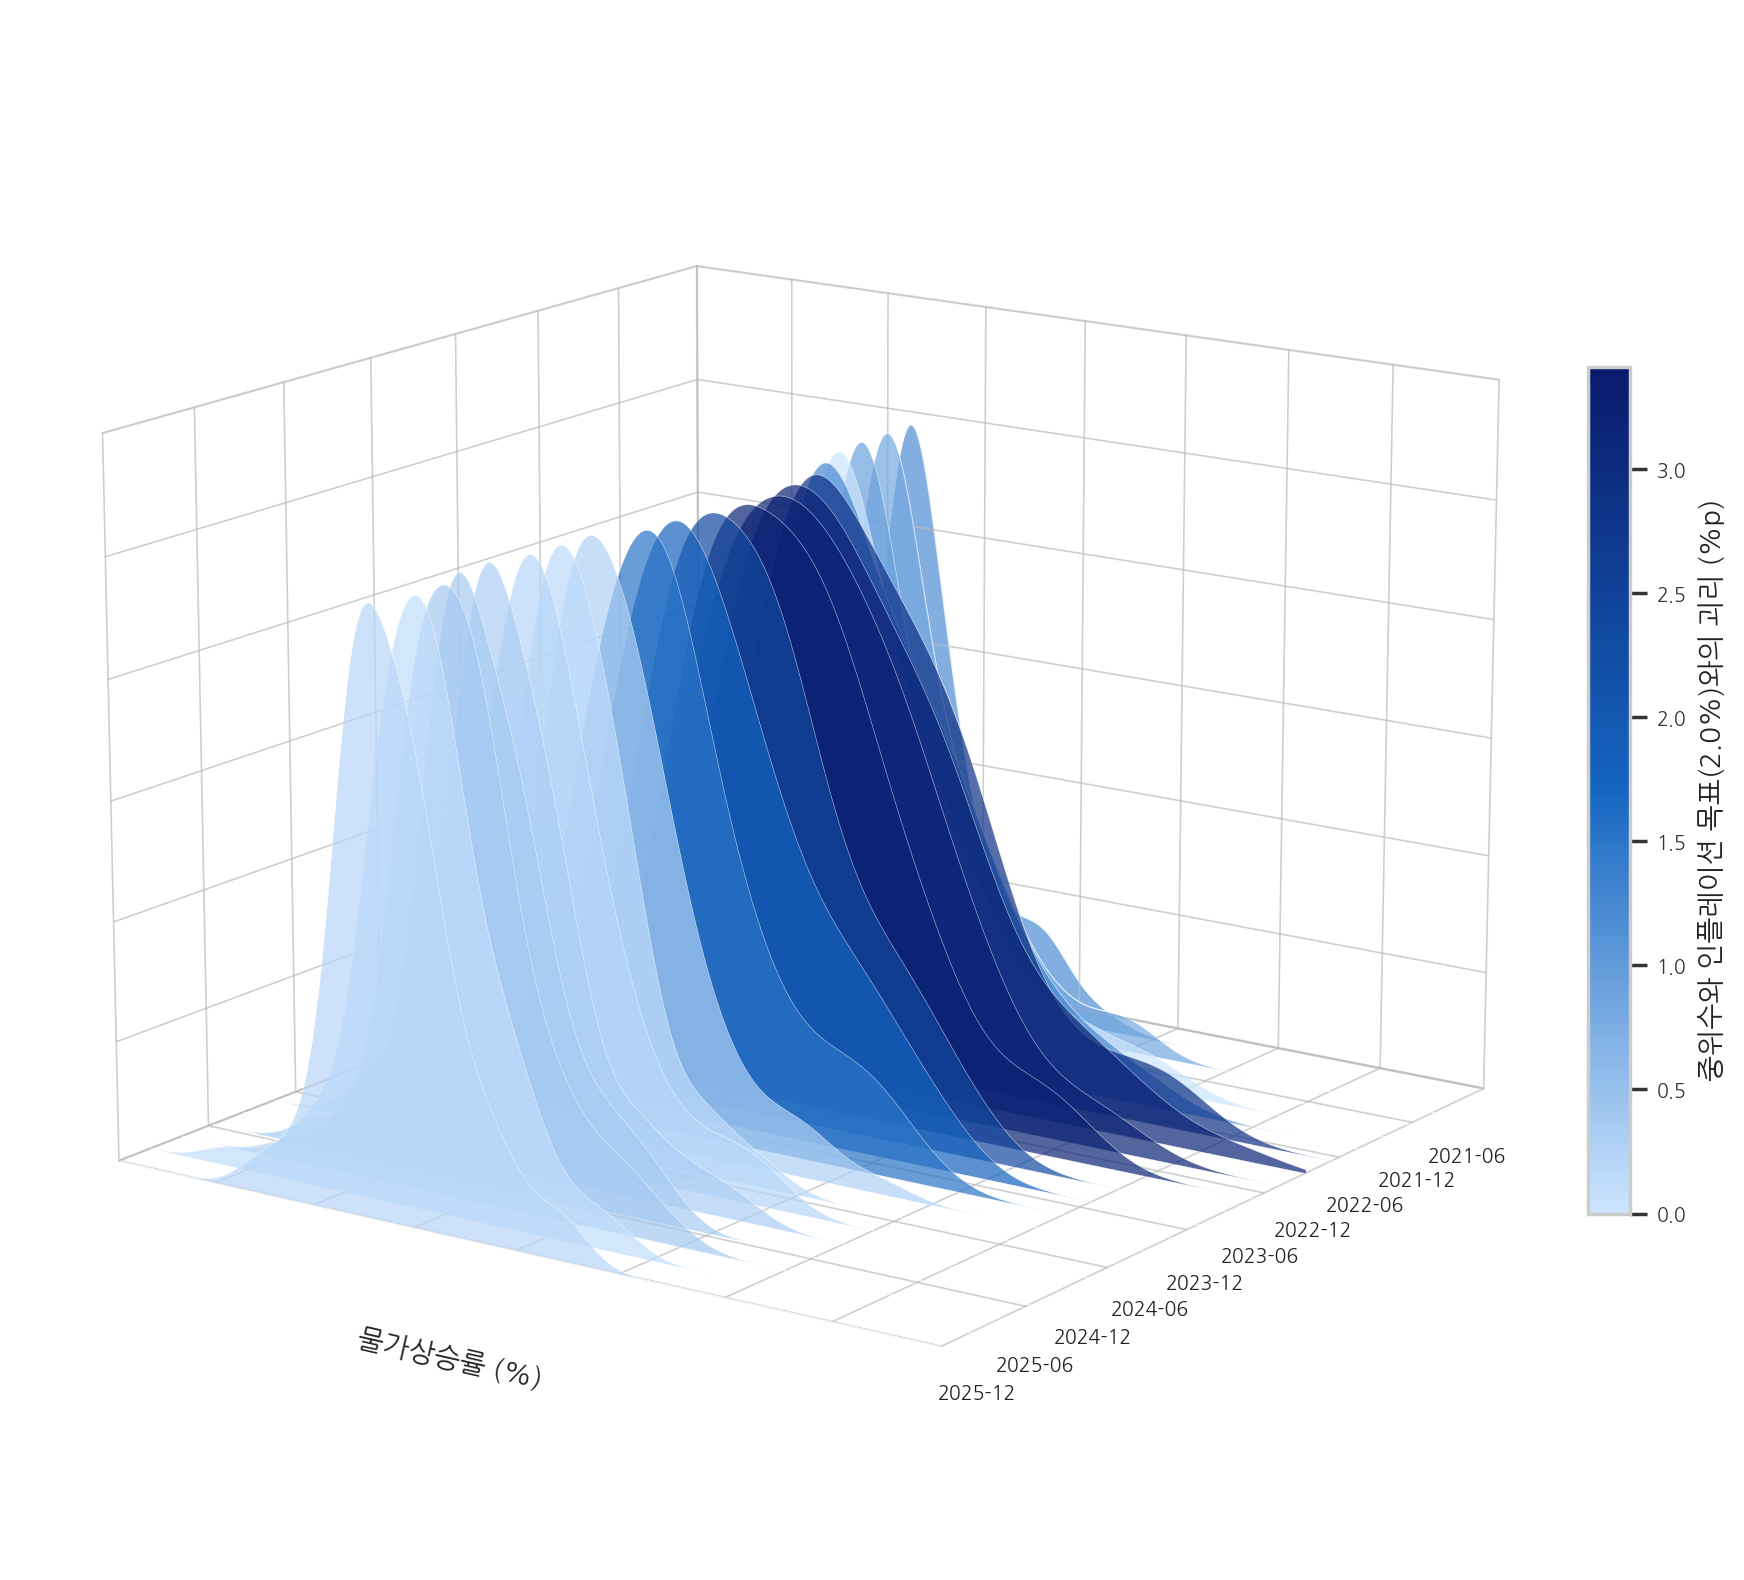

In [ ]:
# 트리밍 데이터 생성
df_trimmed = generate_trimmed_inflation(type_inflation, lags, qrange)

# 날짜 목록 정리
all_dates  = sorted(df_trimmed['mdate'].unique())
plot_dates = (
    [d for d in all_dates if int(d.split('-')[1]) in [3, 6, 9, 12]]
    if quarterly_only else all_dates
)
quarter_dates = [d for d in plot_dates if int(d.split('-')[1]) in [6, 12]]

# x축 범위
all_vals = df_trimmed.loc[df_trimmed['mdate'].isin(plot_dates), 'trimmed values'].values
x_min    = np.floor(all_vals.min()) - 2
x_max    = np.ceil(all_vals.max())  + 2
x_grid   = np.linspace(x_min, x_max, 300)
z_max    = 1.2  # z축 상한 (정규화 후 최대값 1.0의 1.2배)

# 월별 중위수 계산 (컬러 매핑용)
medians = {
    d: np.median(df_trimmed.loc[df_trimmed['mdate'] == d, 'trimmed values'].values)
    for d in all_dates
    if len(df_trimmed.loc[df_trimmed['mdate'] == d]) >= 2
}
deviations_abs = np.array([abs(medians[d] - target_inflation) for d in all_dates if d in medians])
dev_max = deviations_abs.max()

# 컬러맵 (목표 이탈도 기준)
cmap_dev = LinearSegmentedColormap.from_list('blue_mono', ['#cce5ff', '#1565C0', '#0a1a6b'])

def dev_to_color(d, alpha=0.75):
    t = abs(medians[d] - target_inflation) / dev_max
    r, g, b, _ = cmap_dev(t)
    return (r, g, b, alpha)

# ── 3D Joy Plot 그리기 ────────────────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor='white')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
n = len(plot_dates)

for idx, d in enumerate(plot_dates):
    vals = df_trimmed.loc[df_trimmed['mdate'] == d, 'trimmed values'].values
    if len(vals) < 2:
        continue

    kde   = gaussian_kde(vals, bw_method=0.4)
    y_kde = kde(x_grid)
    y_kde = y_kde / y_kde.max()  # 정규화

    z     = n - 1 - idx
    color = dev_to_color(d)

    verts = [(x_grid[0], 0)] + list(zip(x_grid, y_kde)) + [(x_grid[-1], 0)]
    xs = [v[0] for v in verts]
    ys = [z]   * len(verts)
    zs = [v[1] for v in verts]

    poly = Poly3DCollection([list(zip(xs, ys, zs))],
                            alpha=0.7, facecolor=color,
                            edgecolor='white', linewidth=0.2)
    ax.add_collection3d(poly)
    ax.plot(xs[1:-1], ys[1:-1], zs[1:-1], color='white', linewidth=0.5, alpha=0.8)

# 축 설정
ax.set_xlim([x_min, x_max])
ax.set_ylim([0, n])
ax.set_zlim([0, z_max])

# 수동 그리드
gc, gl, ga = '#bbbbbb', 0.6, 0.7
x_ticks = np.arange(x_min, x_max + 1, 5)
y_ticks = np.linspace(0, n, 8)
z_ticks = np.arange(0, z_max + 0.01, 0.2)

for xv in x_ticks:
    ax.plot([xv, xv], [0, n], [0, 0], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([x_min, x_max], [yv, yv], [0, 0], color=gc, lw=gl, alpha=ga)
for xv in x_ticks:
    ax.plot([xv, xv], [n, n], [0, z_max], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([x_min, x_max], [n, n], [zv, zv], color=gc, lw=gl, alpha=ga)
for yv in y_ticks:
    ax.plot([x_min, x_min], [yv, yv], [0, z_max], color=gc, lw=gl, alpha=ga)
for zv in z_ticks:
    ax.plot([x_min, x_min], [0, n], [zv, zv], color=gc, lw=gl, alpha=ga)

ax.grid(False)
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#dddddd')

# y축 눈금 (분기 레이블)
q_indices = [n - 1 - plot_dates.index(d) for d in quarter_dates if d in plot_dates]
ax.set_yticks(q_indices)
ax.set_yticklabels([d for d in quarter_dates if d in plot_dates], fontsize=7, color='#222222')
ax.yaxis._axinfo['tick']['inward_factor']  = 0
ax.yaxis._axinfo['tick']['outward_factor'] = 0

ax.set_xlabel('물가상승률 (%)', labelpad=10, color='#222222', fontsize=10)
ax.set_ylabel('',              labelpad=12, color='#222222', fontsize=9)
ax.set_zlabel('',              labelpad=8,  color='#222222', fontsize=9)
ax.tick_params(axis='x', colors='#333333', labelsize=10)
ax.set_xticks([])
ax.tick_params(axis='z', colors='#333333', labelsize=8, labelleft=False, length=0)
ax.set_zticks([])

# 컬러바
sm = plt.cm.ScalarMappable(cmap=cmap_dev, norm=plt.Normalize(vmin=0, vmax=dev_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01, aspect=20)
cbar.set_label(f'중위수와 인플레이션 목표({target_inflation}%)와의 괴리 (%p)',
               fontsize=10, color='#222222')
cbar.ax.tick_params(labelsize=7, colors='#333333')
cbar.outline.set_edgecolor('#cccccc')

ax.view_init(elev=15, azim=-55)
plt.tight_layout()
save_fig('inf_joyplot_3d')
plt.show()

Saving figure → /content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/figures/inf_joyplot_2d.png


/tmp/ipykernel_2673/2286486876.py:6: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


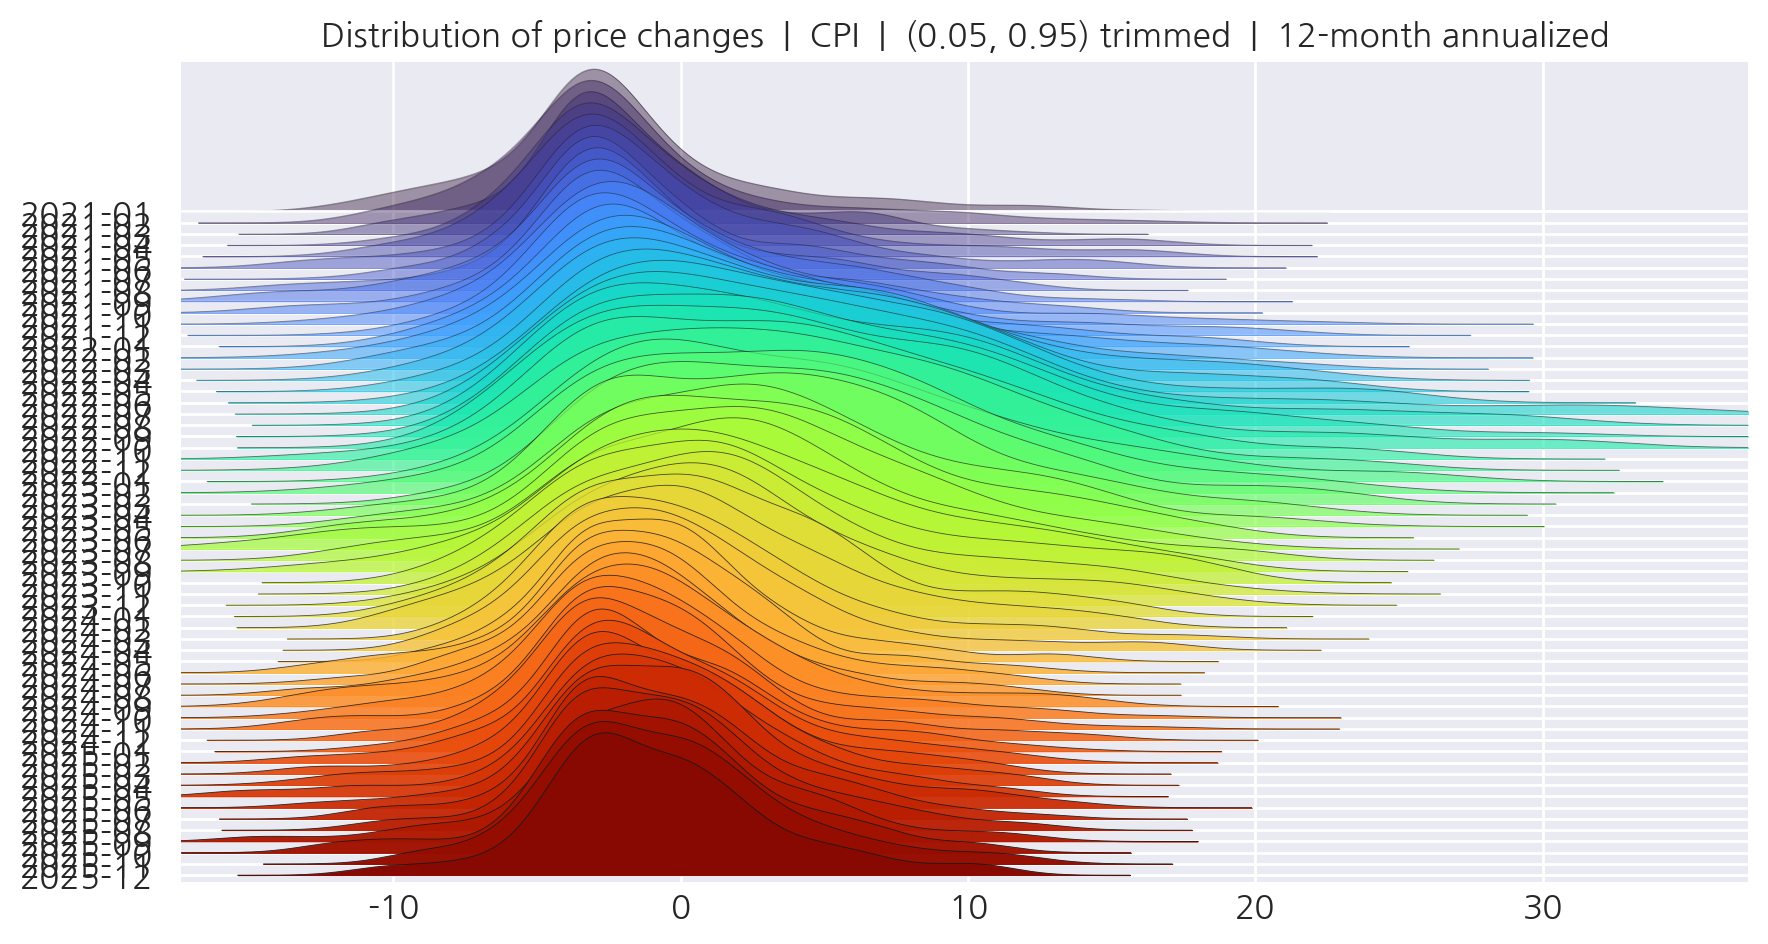

In [ ]:
# ── 2D Joy Plot (joypy 라이브러리) ────────────────────────────
fig, axes = joypy.joyplot(
    df_trimmed,
    by='mdate',
    range_style='own',
    ylim='own',
    fade=True,
    linewidth=0.3,
    colormap=cm.turbo,
    grid=True,
    title=(f'Distribution of price changes  |  {type_inflation}  '
           f'|  ({qrange[0]}, {qrange[1]}) trimmed  '
           f'|  {lags}-month annualized')
)

for a in axes[:-1]:
    a.set_xlim([-10, 30])

save_fig('inf_joyplot_2d')
plt.show()